In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import features as ft
import re
import pyarrow

In [3]:
os.getcwd()

'c:\\Users\\javie\\OneDrive - INSTITUTO TECNOLOGICO AUTONOMO DE MEXICO\\MaestriaEnCienciaDeDatos\\EstanciaDeInvestigacion\\Popocatepelt\\PopocatepetlVolcano\\src'

In [4]:
features_df = pd.read_parquet(r"..\data\features\features.parquet", engine="pyarrow")

In [5]:
# Apply filters to the time series of the features
features_df = features_df[(features_df['energy']>=0)&(features_df['kurtosis']<2500)&(features_df['frequency_index']>=-3)&(features_df['entropy']>=0)&(features_df['entropy']<15000)]
features_df['energy'] = np.log10(features_df['energy'])
features_df['kurtosis'] = np.log10(features_df['kurtosis'])

In [6]:
features_df.columns

Index(['timestamp', 'energy', 'kurtosis', 'frecuency_index', 'entropy',
       'frequency_index'],
      dtype='object')

In [7]:
features_df = features_df.drop('frecuency_index', axis = 1)
features_df_1_month = features_df[features_df['timestamp']<"2022-02-01"]
features_df_1_month

,timestamp,energy,kurtosis,entropy,frequency_index
0,2022-01-01 00:05:00,7.074324,0.633977,6743.988806,-0.005959
1,2022-01-01 00:10:00,7.020175,0.632777,7043.316623,-0.109812
2,2022-01-01 00:15:00,7.011306,0.751629,7175.473832,0.032564
3,2022-01-01 00:20:00,7.010472,0.750180,7186.277967,0.065660
4,2022-01-01 00:25:00,6.986411,0.732571,7290.097859,-0.179743
...,...,...,...,...,...
8892,2022-01-31 23:35:00,8.830721,2.334161,1668.982751,0.629002
8893,2022-01-31 23:40:00,8.817154,2.361190,1705.372009,0.451853
8894,2022-01-31 23:45:00,8.051987,0.780485,2927.230991,0.083474
8895,2022-01-31 23:50:00,7.990021,0.815191,3100.668472,0.158434


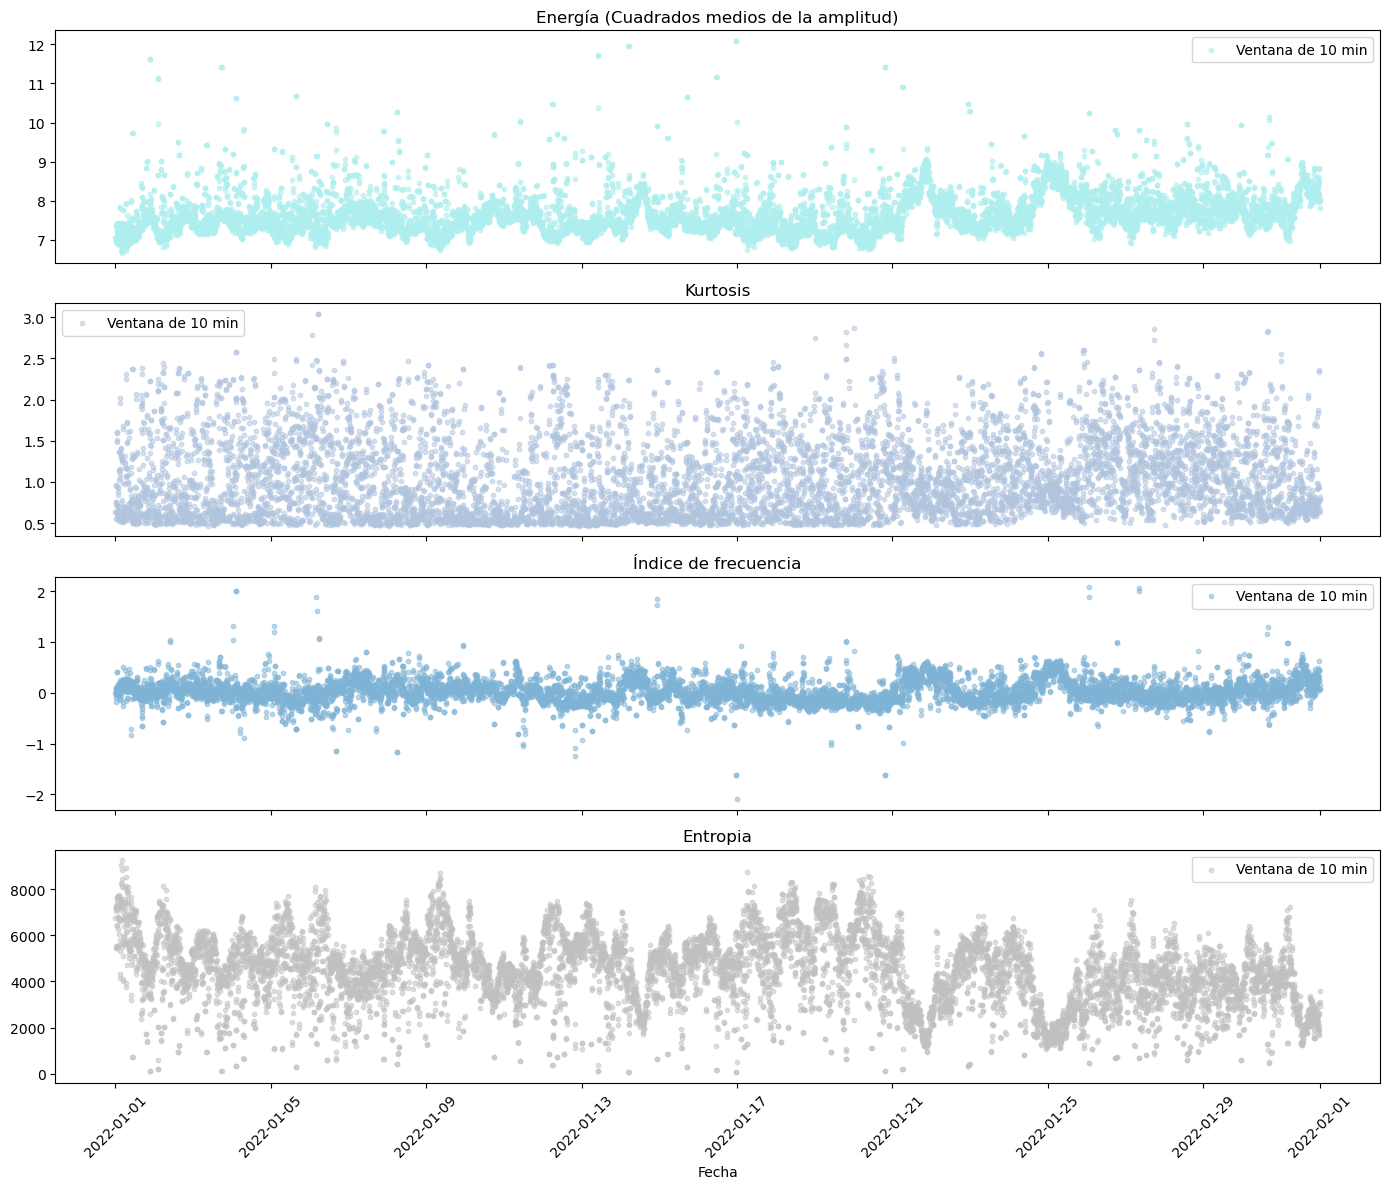

In [8]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
axes[0].scatter(features_df_1_month['timestamp'], features_df_1_month['energy'], color='paleturquoise', s=10, alpha=0.6, label="Ventana de 10 min")
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(loc='best')

axes[1].scatter(features_df_1_month['timestamp'], features_df_1_month['kurtosis'], color='lightsteelblue', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[1].set_title('Kurtosis')
axes[1].legend(loc='best')

axes[2].scatter(features_df_1_month['timestamp'], features_df_1_month['frequency_index'], color='#7FB3D5', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[2].set_title('Índice de frecuencia')
axes[2].legend(loc='best')

axes[3].scatter(features_df_1_month['timestamp'], features_df_1_month['entropy'], color='silver', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(loc='best')

plt.xticks(rotation=45)
plt.tight_layout()

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

In [18]:
# Drop rows with missing values
features_df_1_month = features_df_1_month.dropna()

variables = [
        'energy',
        'kurtosis',
        'frequency_index',
        'entropy'
    ]
clustering_data = features_df_1_month[variables]

# Crea y entrena un escalador (Robust scaler)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(clustering_data)

df_scaled = pd.DataFrame(scaled_data, columns = variables, index=clustering_data.index)

X = df_scaled

In [15]:
X

,energy,kurtosis,frequency_index,entropy
0,0.073703,0.065063,0.499957,0.726940
1,0.063698,0.064596,0.475039,0.759512
2,0.062059,0.110803,0.509200,0.773893
3,0.061905,0.110239,0.517141,0.775068
4,0.057459,0.103394,0.458259,0.786366
...,...,...,...,...
8892,0.398233,0.726048,0.652309,0.174697
8893,0.395726,0.736556,0.609804,0.178657
8894,0.254346,0.122021,0.521415,0.311615
8895,0.242896,0.135514,0.539401,0.330488


In [16]:
# Trata con differentes valores para k
inertia = []
silh = []
k_s = np.arange(2, 16)
for k in k_s:
  km_model = KMeans(n_clusters=k).fit(X)
  inertia.append(km_model.inertia_)
  silh.append(silhouette_score(X, km_model.labels_))

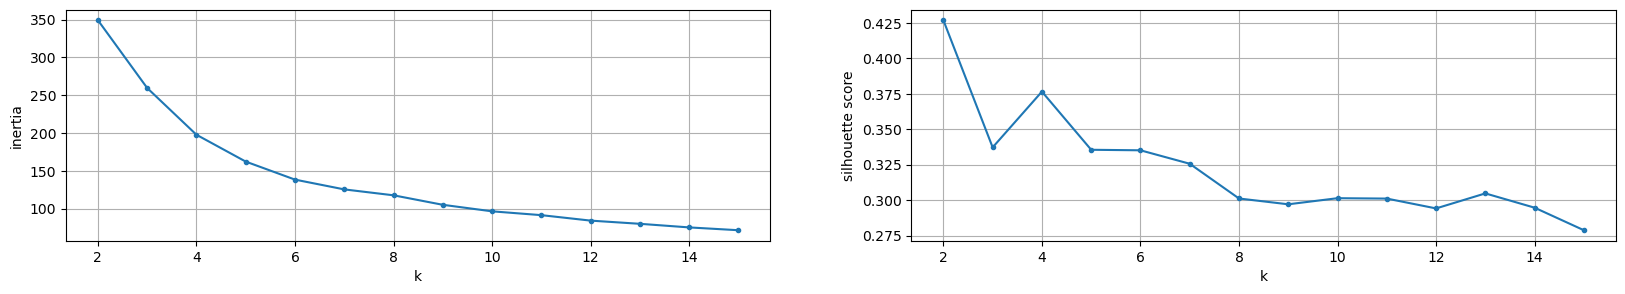

In [17]:
# Plot results
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(k_s, inertia, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('inertia')
plt.subplot(1, 2, 2)
plt.plot(k_s, silh, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.show()

In [19]:
# Repite k-means con el mejor número k
km_model = KMeans(n_clusters = 4).fit(X)

clustering_data['timestamp'] = features_df_1_month['timestamp']

clustering_data['labels'] = km_model.labels_

<Figure size 1600x1200 with 0 Axes>

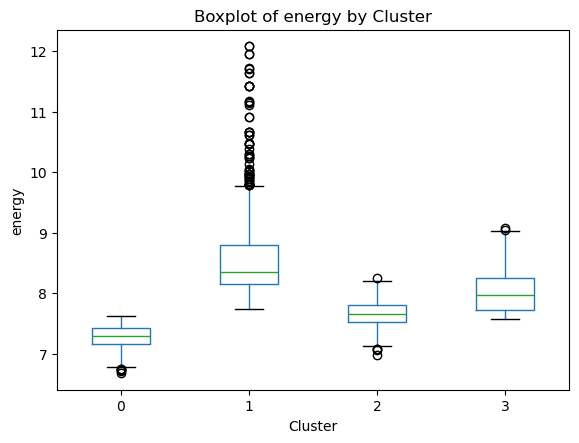

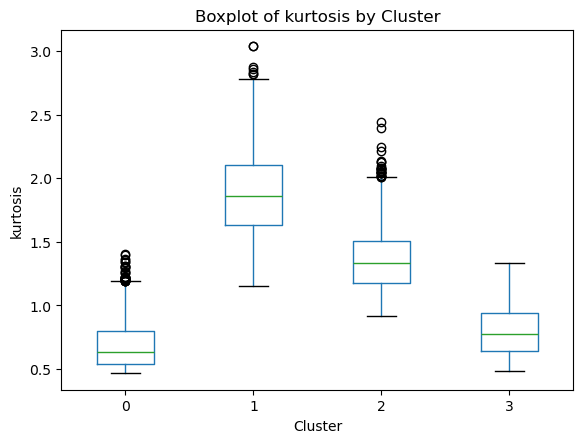

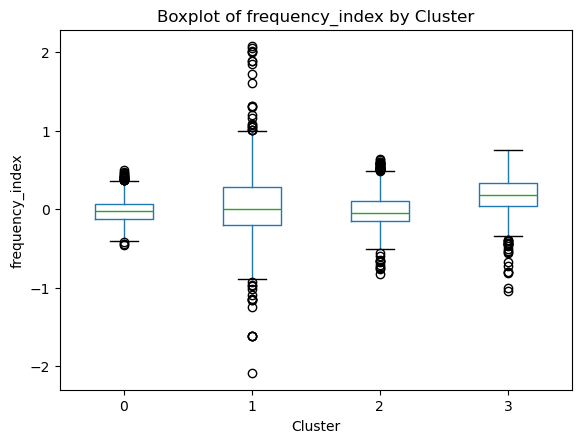

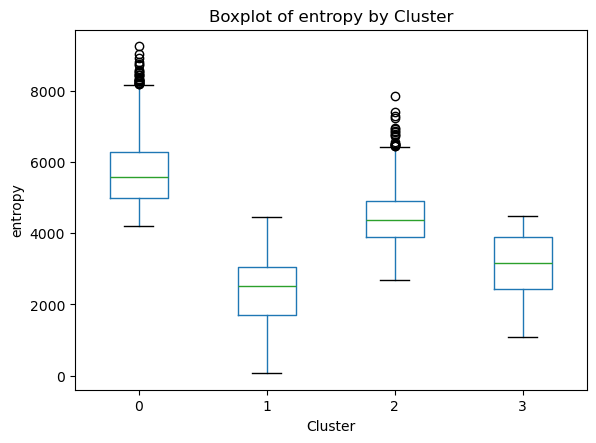

In [20]:
plt.figure(figsize=(16, 12))
for column in variables:
    clustering_data.boxplot(column=column, by='labels', grid=False)
    plt.title(f'Boxplot of {column} by Cluster')
    plt.suptitle('')  # Suppress the default title
    plt.xlabel('Cluster')
    plt.ylabel(column)

plt.show()

In [21]:
# Sort clustering data by timestamp
clustering_data = clustering_data.sort_values(by='timestamp')

In [22]:
clustering_data[['labels','timestamp']].groupby('labels').count()

,timestamp
labels,
0,3649
1,1142
2,2333
3,1769


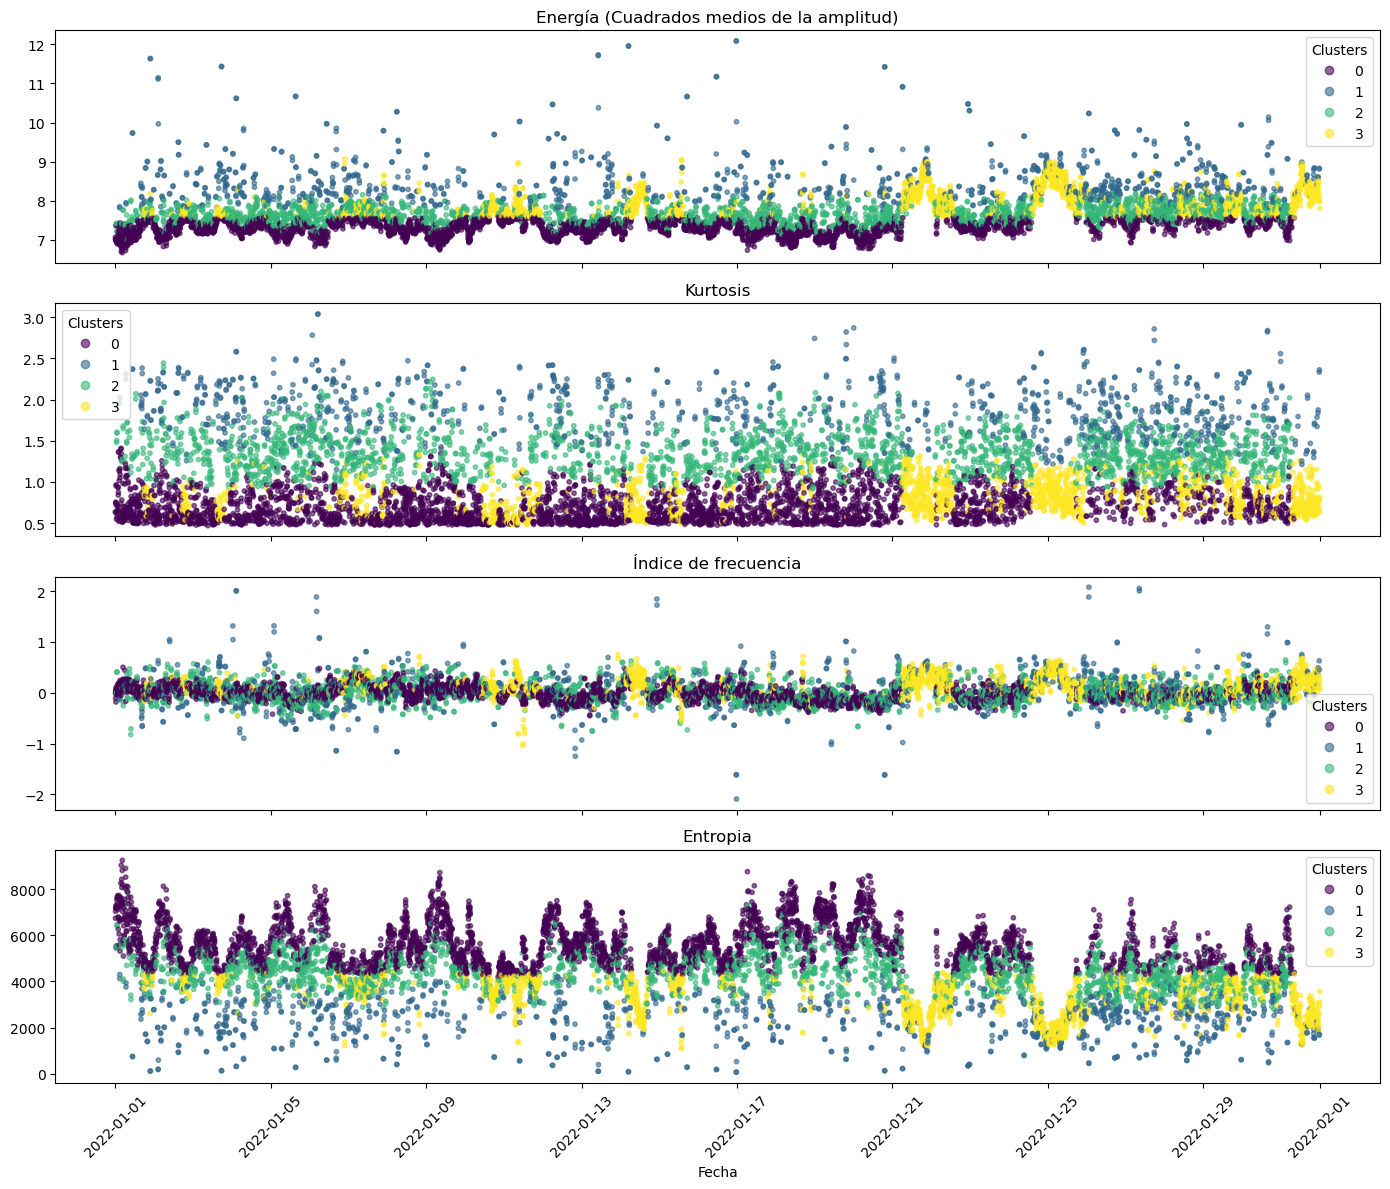

In [24]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data['timestamp'], clustering_data['energy'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data['timestamp'], clustering_data['kurtosis'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data['timestamp'], clustering_data['frequency_index'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data['timestamp'], clustering_data['entropy'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")

plt.xticks(rotation=45)
plt.tight_layout()

In [25]:
features_df_2nd_month = features_df[(features_df['timestamp']<"2022-03-01") & (features_df['timestamp']>="2022-02-01")]

# Drop rows with missing values
features_df_2nd_month = features_df_2nd_month.dropna()

clustering_data_2 = features_df_2nd_month[variables]

scaled_data_2 = scaler.transform(clustering_data_2)

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled_2 = pd.DataFrame(scaled_data_2, columns=variables, index=clustering_data_2.index)

X_2 = df_scaled_2

X_2

,energy,kurtosis,frequency_index,entropy
8897,0.254953,0.235264,0.481475,0.322242
8898,0.267607,0.178068,0.544935,0.294227
8899,0.257985,0.120230,0.562377,0.303615
8900,0.228704,0.107984,0.543630,0.350642
8901,0.278873,0.672364,0.395679,0.307553
...,...,...,...,...
16928,0.402838,0.479288,0.616487,0.163898
16929,0.275506,0.203983,0.436176,0.292756
16930,0.208020,0.235545,0.507838,0.406647
16931,0.259063,0.219239,0.444691,0.319814


In [32]:
# Predict clusters for new data using the same centroids
labels_2 = km_model.predict(X_2)
clustering_data_2['timestamp'] = features_df_2nd_month['timestamp']
clustering_data_2['labels'] = labels_2

In [34]:
clustering_data_all = pd.concat([clustering_data, clustering_data_2], axis=0)

# Optional: sort by timestamp
clustering_data_all = clustering_data_all.sort_values('timestamp')

clustering_data_all

,energy,kurtosis,frequency_index,entropy,timestamp,labels
0,7.074324,0.633977,-0.005959,6743.988806,2022-01-01 00:05:00,0
1,7.020175,0.632777,-0.109812,7043.316623,2022-01-01 00:10:00,0
2,7.011306,0.751629,0.032564,7175.473832,2022-01-01 00:15:00,0
3,7.010472,0.750180,0.065660,7186.277967,2022-01-01 00:20:00,0
4,6.986411,0.732571,-0.179743,7290.097859,2022-01-01 00:25:00,0
...,...,...,...,...,...,...
16928,8.855648,1.699446,0.479707,1569.737748,2022-02-28 23:35:00,1
16929,8.166508,0.991308,-0.271779,2753.917439,2022-02-28 23:40:00,3
16930,7.801269,1.072489,0.026886,3800.556831,2022-02-28 23:45:00,2
16931,8.077517,1.030549,-0.236294,3002.579702,2022-02-28 23:50:00,3


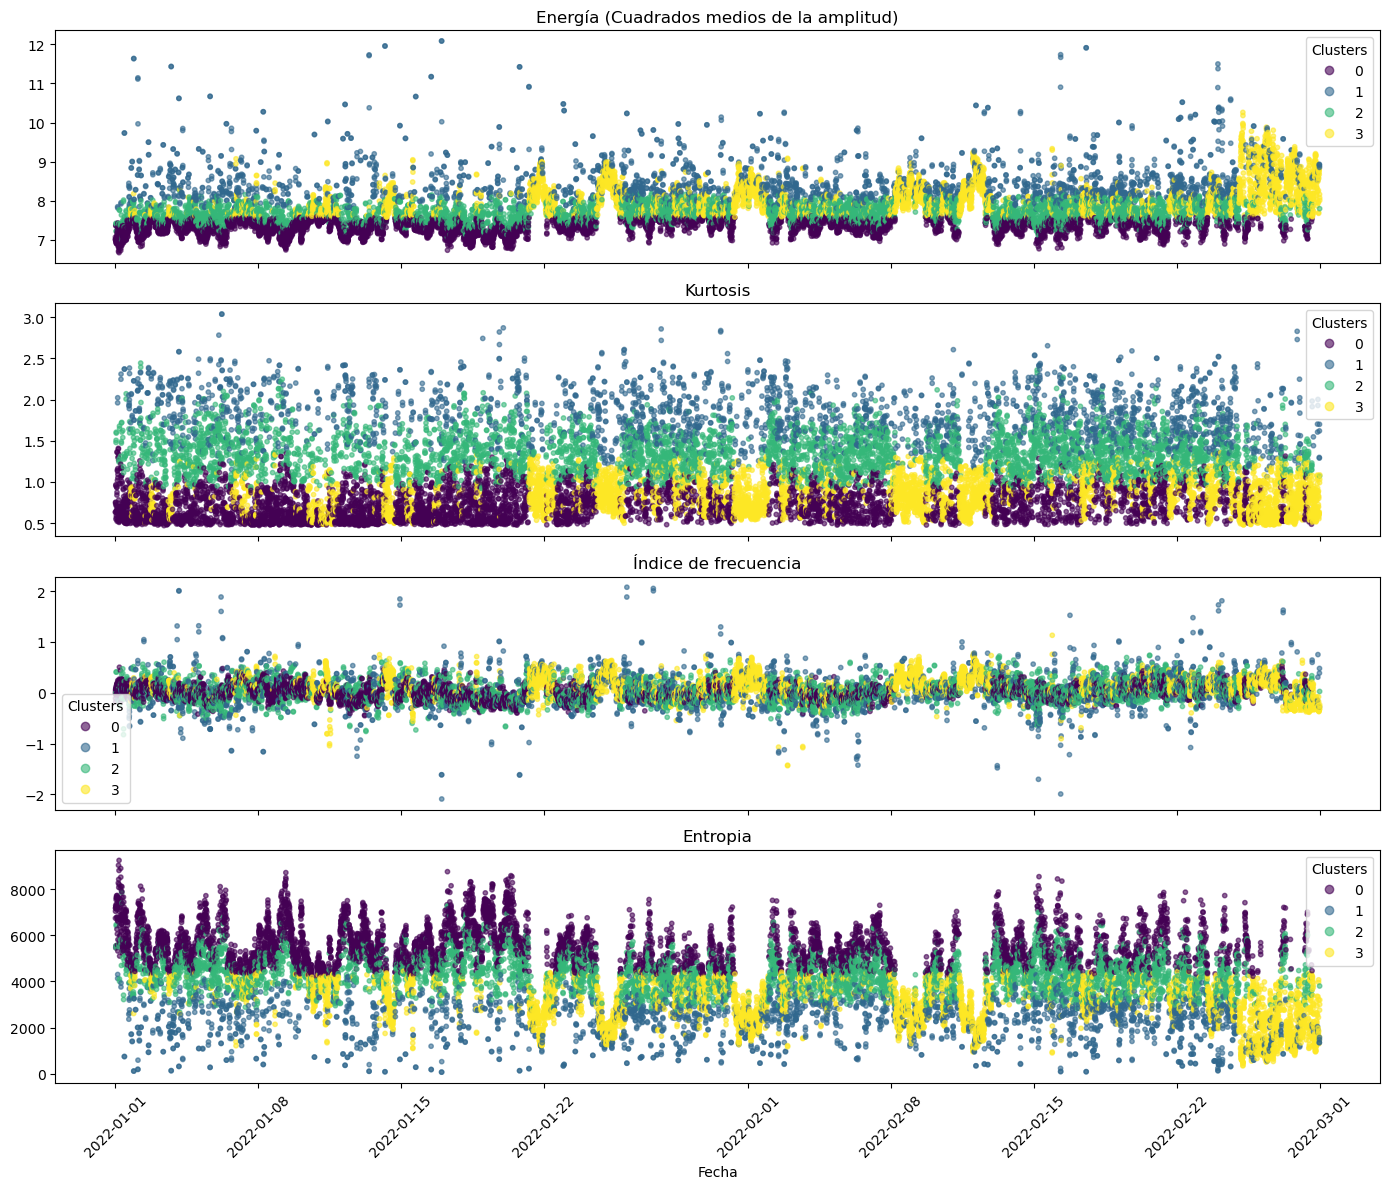

In [35]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_all['timestamp'], clustering_data_all['energy'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_all['timestamp'], clustering_data_all['kurtosis'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_all['timestamp'], clustering_data_all['frequency_index'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_all['timestamp'], clustering_data_all['entropy'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")

plt.xticks(rotation=45)
plt.tight_layout()

In [36]:
features_df_rest_all = features_df[(features_df['timestamp']>="2022-03-01")]

# Drop rows with missing values
features_df_rest_all = features_df_rest_all.dropna()

clustering_data_3 = features_df_rest_all[variables]

scaled_data_3 = scaler.transform(clustering_data_3)

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled_3 = pd.DataFrame(scaled_data_3, columns=variables, index=clustering_data_3.index)

X_3 = df_scaled_3

X_3

,energy,kurtosis,frequency_index,entropy
16933,0.339621,0.393237,0.459042,0.220255
16934,0.318454,0.171187,0.436877,0.228243
16935,0.303609,0.216514,0.434536,0.251709
16936,0.321543,0.194597,0.434874,0.228954
16937,0.351714,0.111944,0.438668,0.186947
...,...,...,...,...
244232,0.363624,0.614950,0.504667,0.197731
244233,0.363258,0.617269,0.511897,0.200043
244234,0.311873,0.423459,0.552525,0.246969
244235,0.318483,0.395551,0.553772,0.236281


In [37]:
# Predict clusters for new data using the same centroids
labels_3 = km_model.predict(X_3)
clustering_data_3['timestamp'] = features_df_rest_all['timestamp']
clustering_data_3['labels'] = labels_3

clustering_data_all_with_rest = pd.concat([clustering_data_all, clustering_data_3], axis=0)

clustering_data_all_with_rest = clustering_data_all_with_rest.sort_values('timestamp')

clustering_data_all_with_rest


,energy,kurtosis,frequency_index,entropy,timestamp,labels
0,7.074324,0.633977,-0.005959,6743.988806,2022-01-01 00:05:00,0
1,7.020175,0.632777,-0.109812,7043.316623,2022-01-01 00:10:00,0
2,7.011306,0.751629,0.032564,7175.473832,2022-01-01 00:15:00,0
3,7.010472,0.750180,0.065660,7186.277967,2022-01-01 00:20:00,0
4,6.986411,0.732571,-0.179743,7290.097859,2022-01-01 00:25:00,0
...,...,...,...,...,...,...
244232,8.643414,2.048395,0.013671,1880.653717,2024-04-30 23:35:00,1
244233,8.641434,2.054361,0.043806,1901.904995,2024-04-30 23:40:00,1
244234,8.363330,1.555841,0.213128,2333.147244,2024-04-30 23:45:00,1
244235,8.399109,1.484056,0.218329,2234.924698,2024-04-30 23:50:00,1


C:\Users\javie\AppData\Local\Temp\ipykernel_20584\3013477763.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\javie\miniconda3\envs\estancia_popocatepetl\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\javie\miniconda3\envs\estancia_popocatepetl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


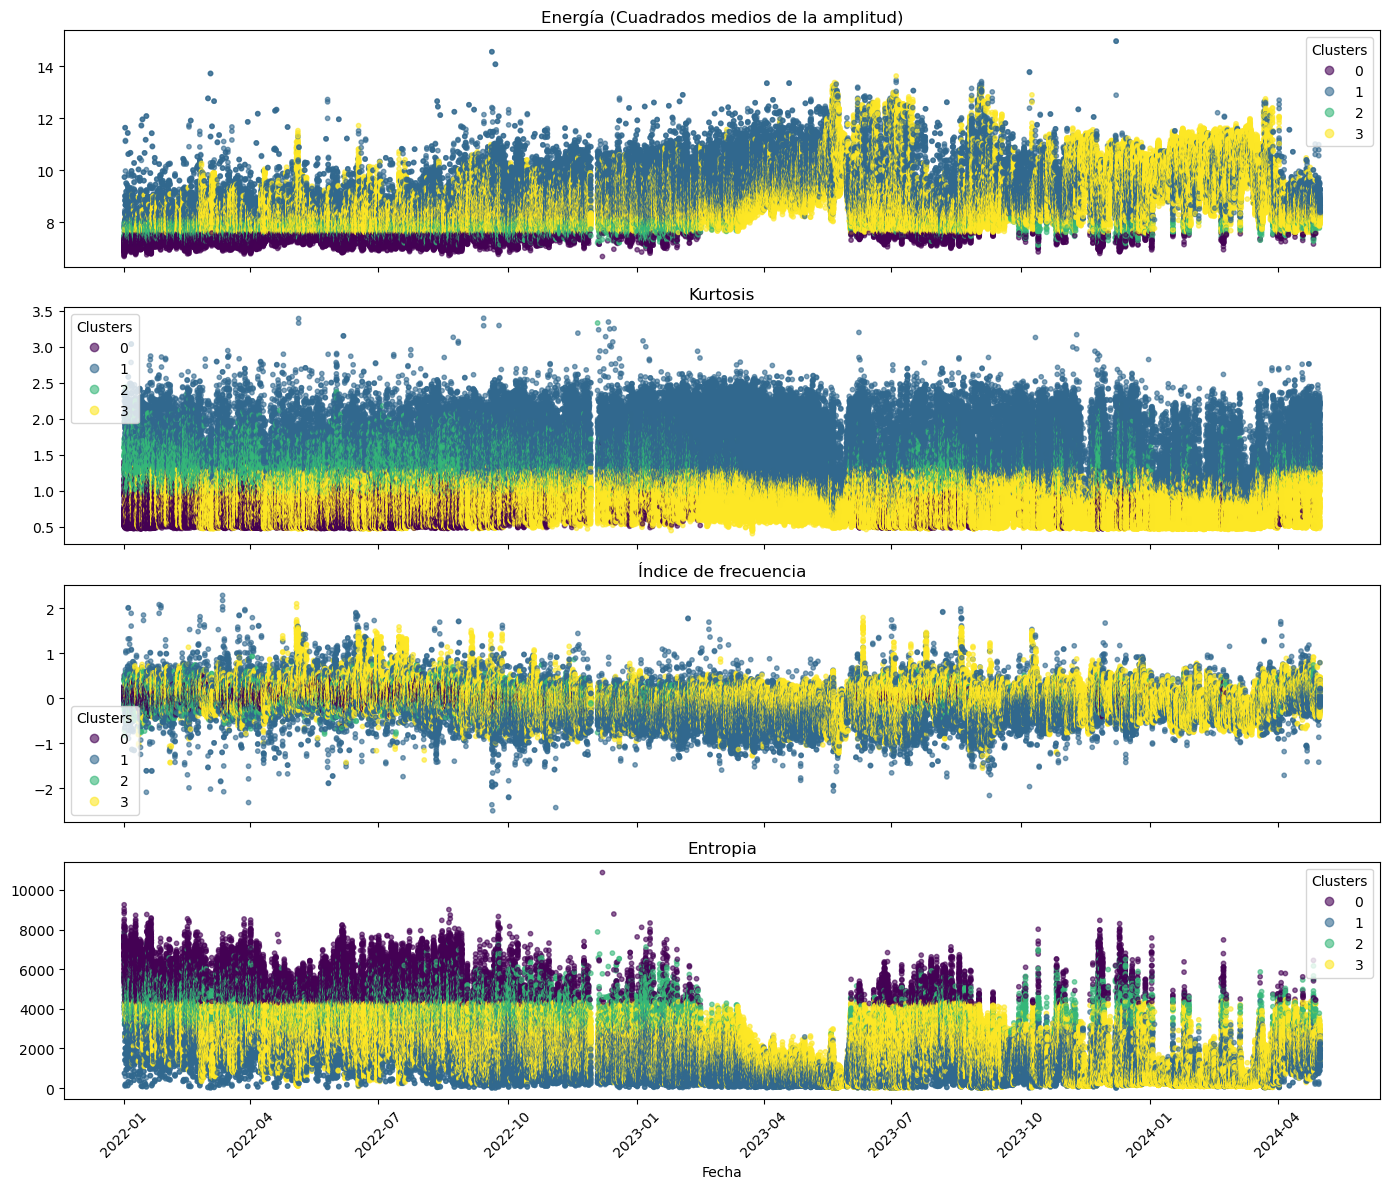

In [38]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_all_with_rest['timestamp'], clustering_data_all_with_rest['energy'], c=clustering_data_all_with_rest['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_all_with_rest['timestamp'], clustering_data_all_with_rest['kurtosis'], c=clustering_data_all_with_rest['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_all_with_rest['timestamp'], clustering_data_all_with_rest['frequency_index'], c=clustering_data_all_with_rest['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_all_with_rest['timestamp'], clustering_data_all_with_rest['entropy'], c=clustering_data_all_with_rest['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")

plt.xticks(rotation=45)
plt.tight_layout()